# LLM-DHRP: Language-Informed Differentiable Hierarchical Risk Parity

**Full Experimental Pipeline (Colab GPU)**

Run all cells in order. Upload your `HRP_AI` folder to Google Drive first, then cell 1 mounts Drive and sets up the environment.

In [1]:
# === CELL 1: SETUP ===
import os, sys, subprocess, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        pass  # already mounted

    CANDIDATE_PATHS = [
        "/content/drive/MyDrive/HRP_AI",
        "/content/drive/My Drive/HRP_AI",
        "/content/drive/MyDrive/Code/HRP_AI",
        "/content/drive/MyDrive/Projects/HRP_AI",
        "/content/drive/MyDrive/dhrp-allocation",
    ]
    REPO_PATH = None
    for p in CANDIDATE_PATHS:
        if os.path.exists(p):
            REPO_PATH = p
            break

    if REPO_PATH is None:
        REPO_PATH = "/content/HRP_AI"
        if not os.path.exists(REPO_PATH):
            print("HRP_AI not found on Drive - cloning from GitHub...")
            subprocess.check_call([
                "git", "clone",
                "https://github.com/joseamador0898/dhrp-allocation.git",
                REPO_PATH,
            ])
        else:
            # Always pull latest to stay in sync
            print("Pulling latest changes...")
            subprocess.call(["git", "-C", REPO_PATH, "fetch", "--all"],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            subprocess.call(["git", "-C", REPO_PATH, "reset", "--hard", "origin/main"],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    os.chdir(REPO_PATH)

    # Copy .env from Drive if available, otherwise prompt upload
    env_candidates = [
        '/content/drive/MyDrive/HRP_AI/.env',
        '/content/drive/MyDrive/.env',
        '/content/drive/My Drive/HRP_AI/.env',
    ]
    if not os.path.exists('.env'):
        for ep in env_candidates:
            if os.path.exists(ep):
                import shutil
                shutil.copy(ep, '.env')
                print(f'Copied .env from {ep}')
                break
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print(f"Working dir: {os.getcwd()}")

    !pip install -q torch transformers tokenizers huggingface-hub         requests pandas-datareader fredapi cvxpy seaborn python-dotenv         scipy statsmodels bitsandbytes accelerate feedparser datasets yfinance \
        google-generativeai spgci
else:
    parent = os.path.abspath("..")
    if parent not in sys.path:
        sys.path.insert(0, parent)

import warnings
warnings.filterwarnings("ignore")

# --- Clean stale results from previous runs ---
def clean_stale_results():
    patterns = [
        "results/*.csv", "results/*.png",
        "results/models/*.pt",
        "results/features/*.npz", "results/features/*.csv",
        "results/full/*.csv",
        "results/figures/*.png",
    ]
    total = 0
    for pat in patterns:
        for f in glob.glob(pat):
            os.remove(f)
            total += 1
    if total:
        print(f"Cleaned {total} stale result files.")

clean_stale_results()

for d in ['results', 'results/figures', 'results/models', 'results/features', 'results/full']:
    os.makedirs(d, exist_ok=True)

import torch
import numpy as np
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
device = "cuda" if torch.cuda.is_available() else "cpu"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pulling latest changes...
Working dir: /content/HRP_AI
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
# === CELL 2: LOAD PRICE + VOLUME DATA (all 3 universes) ===
from datetime import datetime, timedelta
from src.data.price_loader import load_universe, load_fama_french, load_etf_volume_data, UNIVERSES

END = datetime.now().strftime('%Y-%m-%d')
START = (datetime.now() - timedelta(days=10*365)).strftime('%Y-%m-%d')
print(f'Period: {START} to {END}\n')

print(f'=== DM Universe ({len(UNIVERSES["DM"])} ETFs) ===')
DM_prices = load_universe('DM', START, END)

print(f'\n=== EM Universe ({len(UNIVERSES["EM"])} ETFs) ===')
EM_prices = load_universe('EM', START, END)

print(f'\n=== Commodities Universe ({len(UNIVERSES["Commodities"])} ETFs) ===')
CMD_prices = load_universe('Commodities', START, END)

print('\n=== Fama-French Factors ===')
FF = load_fama_french(START, END)

# Load volume data for enhanced features
print('\n=== Volume Data ===')
try:
    DM_vol = load_etf_volume_data(list(UNIVERSES['DM'].values()), START, END)
    EM_vol = load_etf_volume_data(list(UNIVERSES['EM'].values()), START, END)
    CMD_vol = load_etf_volume_data(list(UNIVERSES['Commodities'].values()), START, END)
    print(f'DM volume: {DM_vol.shape}, EM volume: {EM_vol.shape}, CMD volume: {CMD_vol.shape}')
except Exception as e:
    print(f'Volume data unavailable ({e}), proceeding without')
    DM_vol = EM_vol = CMD_vol = None

Period: 2016-04-04 to 2026-04-02

=== DM Universe (20 ETFs) ===
  [cache] SPY: 2514 days
  [cache] QQQ: 2514 days
  [cache] IWM: 2514 days
  [cache] DIA: 2514 days
  [cache] EFA: 2514 days
  [cache] VGK: 2514 days
  [cache] VPL: 2514 days
  [cache] XLF: 2514 days
  [cache] XLK: 2514 days
  [cache] XLE: 2514 days
  [cache] XLV: 2514 days
  [cache] XLI: 2514 days
  [cache] XLB: 2514 days
  [cache] XLU: 2514 days
  [cache] XLP: 2514 days
  [cache] XLY: 2514 days
  [cache] XLRE: 2514 days
  [cache] TLT: 2514 days
  [cache] GLD: 2514 days
  [cache] UUP: 2514 days
  Total: 2514x20 assets, coverage: 100.0%

=== EM Universe (14 ETFs) ===
  [cache] EEM: 2514 days
  [cache] EWZ: 2514 days
  [cache] FXI: 2514 days
  [cache] EWY: 2514 days
  [cache] EWT: 2514 days
  [cache] EWH: 2514 days
  [cache] THD: 2514 days
  [cache] VNM: 2514 days
  [cache] INDA: 2514 days
  [cache] EWW: 2514 days
  [cache] EWJ: 2514 days
  [cache] TUR: 2514 days
  [cache] EZA: 2514 days
  [cache] EPOL: 2514 days
  Total: 2

In [3]:
# === CELL 3: LOAD HEADLINES (all sources) ===
from src.data.text_loader import load_all_headlines
import pandas as pd

# Collect headlines from ALL available sources (yfinance + RSS + PhraseBank + FiQA)
all_tickers = (
    list(UNIVERSES['DM'].values()) +
    list(UNIVERSES['EM'].values()) +
    list(UNIVERSES['Commodities'].values())
)
all_tickers = list(set(all_tickers))

print(f'Fetching headlines for {len(all_tickers)} tickers from all sources...')
headlines_df = load_all_headlines(
    all_tickers, START, END,
    max_headlines=100,
    use_rss=True,
    use_phrasebank=True,
    use_fiqa=True,
)
print(f'\nTotal headlines: {len(headlines_df)}')
if not headlines_df.empty:
    print(f'Date range: {headlines_df["date"].min()} to {headlines_df["date"].max()}')
    print(f'Tickers with news: {headlines_df["ticker"].nunique()}')
    print(f'Sources: {headlines_df["source"].value_counts().to_dict()}')

Fetching headlines for 43 tickers from all sources...
  Loading yfinance headlines...
    yfinance: 345 headlines
  Loading RSS headlines...
    RSS: 100 headlines
  Loading Financial PhraseBank...
Financial PhraseBank unavailable: Dataset scripts are no longer supported, but found financial_phrasebank.py
  Loading FiQA dataset...


    FiQA: 1213 sentences
  Total unique headlines: 1441

Total headlines: 1441
Date range: 2025-05-07 00:00:00 to 2026-04-02 20:24:40.464904
Tickers with news: 42
Sources: {'FiQA': 1111, 'Zacks': 62, 'Yahoo Finance': 48, 'MT Newswires': 46, '24/7 Wall St.': 34, 'CNBC Top News': 30, 'Barrons.com': 25, 'Motley Fool': 11, 'Barchart': 10, 'MarketWatch': 10, 'MoneyShow': 10, 'etf.com': 9, 'Moby': 6, 'MarketBeat': 6, 'Yahoo Finance Video': 5, 'Investing.com': 5, 'The Daily Upside': 4, "Investor's Business Daily": 3, 'GuruFocus.com': 3, 'Oilprice.com': 1, 'The Wall Street Journal': 1, 'StockStory': 1}


In [4]:
# === CELL 4: FINBERT EMBEDDINGS (T4: ~2 min for 1000 headlines) ===
from src.data.llm_features import get_finbert_embeddings

headline_to_emb = {}
if not headlines_df.empty:
    unique_headlines = headlines_df['headline'].unique().tolist()
    print(f'Extracting FinBERT embeddings for {len(unique_headlines)} unique headlines...')

    finbert_embs = get_finbert_embeddings(unique_headlines, batch_size=64, device=device)
    print(f'FinBERT embeddings shape: {finbert_embs.shape}')

    headline_to_emb = {h: finbert_embs[i] for i, h in enumerate(unique_headlines)}
    print(f'VRAM after FinBERT: {torch.cuda.memory_allocated()/1e9:.2f} GB' if torch.cuda.is_available() else 'CPU mode')
else:
    print('No headlines available. Proceeding with price-only features.')

Extracting FinBERT embeddings for 1441 unique headlines...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT embeddings shape: (1441, 768)
VRAM after FinBERT: 0.01 GB


In [5]:
# === CELL 5: QWEN3 STRUCTURED SENTIMENT (auto: 32B on A100, 8B on T4) ===
from src.data.llm_features import _select_qwen_model, get_qwen3_sentiment, sentiment_to_features

qwen_model = _select_qwen_model()
sentiment_by_ticker = {}
if qwen_model and not headlines_df.empty:
    print(f'=== STRUCTURED SENTIMENT ({qwen_model}) ===')
    tickers_with_headlines = headlines_df.groupby('ticker')['headline'].apply(list).to_dict()
    batch_inputs = []
    batch_tickers = []
    for ticker, hdls in tickers_with_headlines.items():
        if len(hdls) >= 3:
            batch_inputs.append(hdls[:15])
            batch_tickers.append(ticker)

    if batch_inputs:
        sentiments = get_qwen3_sentiment(batch_inputs, device=device, model_name=qwen_model)
        for ticker, sent in zip(batch_tickers, sentiments):
            sentiment_by_ticker[ticker] = sentiment_to_features(sent)
        print(f'  Sentiment extracted for {len(sentiment_by_ticker)} tickers')
        if torch.cuda.is_available():
            print(f'  VRAM after Qwen3: {torch.cuda.memory_allocated()/1e9:.2f} GB')
else:
    if not qwen_model:
        print('No GPU available for Qwen3 sentiment. Skipping.')
    else:
        print('No headlines for Qwen3 sentiment. Skipping.')

Loading Qwen3-8B (4-bit)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

VRAM after load: 6.10 GB
Extracting sentiment for 42 tickers...
  1/42...
  10/42...
  20/42...
  30/42...
  40/42...
Sentiment extracted for 42 tickers
VRAM after Qwen3: 6.10 GB


In [6]:
# === CELL 6: BUILD TEXT FEATURE TENSORS ===
from src.data.feature_engineering import build_dataset

def build_text_tensor_for_universe(prices, universe_tickers, headline_to_emb, headlines_df, volume=None):
    """Build (n_samples, n_assets, 768) FinBERT tensor for a universe."""
    X, S, R, H = build_dataset(prices, volume=volume)
    n_samp = X.shape[0]
    n_assets = prices.shape[1]
    ticker_list = list(universe_tickers.values())

    # For each asset, use the average embedding of all its headlines
    asset_embs = np.zeros((n_assets, 768), dtype=np.float32)
    for j, ticker in enumerate(ticker_list):
        ticker_headlines = headlines_df[headlines_df['ticker'] == ticker]['headline'].tolist()
        embs = [headline_to_emb[h] for h in ticker_headlines if h in headline_to_emb]
        if embs:
            asset_embs[j] = np.mean(embs, axis=0)
        elif 'MARKET' in headlines_df['ticker'].values:
            # Use market-level headlines as fallback
            market_headlines = headlines_df[headlines_df['ticker'] == 'MARKET']['headline'].tolist()
            market_embs = [headline_to_emb[h] for h in market_headlines[:20] if h in headline_to_emb]
            if market_embs:
                asset_embs[j] = np.mean(market_embs, axis=0)

    text_tensor = np.tile(asset_embs, (n_samp, 1, 1))
    return text_tensor

# Build text features for each universe
text_dm, text_em, text_cmd = None, None, None

if headline_to_emb:
    print('Building text feature tensors...')
    text_dm = build_text_tensor_for_universe(DM_prices, UNIVERSES['DM'], headline_to_emb, headlines_df, volume=DM_vol)
    text_em = build_text_tensor_for_universe(EM_prices, UNIVERSES['EM'], headline_to_emb, headlines_df, volume=EM_vol)
    text_cmd = build_text_tensor_for_universe(CMD_prices, UNIVERSES['Commodities'], headline_to_emb, headlines_df, volume=CMD_vol)
    print(f'  DM text: {text_dm.shape}')
    print(f'  EM text: {text_em.shape}')
    print(f'  CMD text: {text_cmd.shape}')

    np.savez_compressed('results/features/text_dm.npz', finbert=text_dm)
    np.savez_compressed('results/features/text_em.npz', finbert=text_em)
    np.savez_compressed('results/features/text_cmd.npz', finbert=text_cmd)
    print('Saved to results/features/')
else:
    print('No text features available. Using price-only mode.')

Building text feature tensors...
  DM text: (452, 20, 768)
  EM text: (452, 14, 768)
  CMD text: (452, 10, 768)
Saved to results/features/


In [7]:
# === CELL 7: PER-UNIVERSE DATA SOURCES ===
from src.data.fred_loader import load_fred_data, make_macro_features
from src.data.universe_config import UNIVERSE_DATA_CONFIG
from dotenv import load_dotenv
load_dotenv()

# Set FRED key directly if .env is not available (e.g. Colab clone)
if not os.environ.get('FRED_API_KEY'):
    os.environ['FRED_API_KEY'] = '139e45f095302fed00e434b1158a4ddc'

print('=== PER-UNIVERSE DATA SOURCES ===')

# DM: full US FRED macro (VIX, yield curve, credit, CPI, etc.)
dm_macro = None
if UNIVERSE_DATA_CONFIG['DM']['use_macro']:
    print('\n--- DM: Loading US FRED macro features ---')
    fred_df = load_fred_data(START, END, extended=True)
    if not fred_df.empty:
        dm_macro = make_macro_features(fred_df)
        print(f'  DM macro: {dm_macro.shape}')
        print(f'  Columns: {dm_macro.columns.tolist()[:8]}...')
    else:
        print('  FRED not available.')

# GS Quant macro (DM only): SPX, VIX, NDX, RTY, MXEF, MXWO, MXEA, BCOMTR, DXY, EURUSD, USDJPY
try:
    from src.data.gsquant_loader import load_gs_data
    gs_df = load_gs_data(START, END)
    if not gs_df.empty:
        if dm_macro is not None:
            dm_macro = pd.concat([dm_macro, gs_df], axis=1, join='outer').ffill().bfill()
        else:
            dm_macro = gs_df
        print(f'  DM macro (FRED+GS): {dm_macro.shape}')
except Exception as e:
    print(f'  GS Quant: {e}')

# EM: NO US macro -- text-only conditioning
print('\n--- EM: No US macro (text-only LLM-DHRP) ---')

# Commodities: NO US macro -- text-only conditioning; SPGCI best-effort
print('\n--- Commodities: No US macro (text-only LLM-DHRP) ---')
if UNIVERSE_DATA_CONFIG['Commodities']['spgci']:
    try:
        from src.data.spgci_loader import load_spgci_data
        spgci_df = load_spgci_data(START, END)
        if not spgci_df.empty:
            print(f'  SPGCI features: {spgci_df.shape}')
    except Exception as e:
        print(f'  SPGCI: {e}')

Loading FRED macro features...
Macro features: (2679, 15)
Columns: ['vix', 'yield_curve', 'credit_spread', 'fed_rate', 'consumer_sent', 'unemployment', 'cpi', 'dollar_index', 'yc_change_5d', 'vix_change_5d', 'vix_above_20', 'cs_change_5d', 'sent_change_5d', 'cpi_mom', 'dollar_mom_21d']


In [8]:
# === CELL 8: TRAIN ALL MODELS (DM Universe) ===
from src.training.trainer import train_dhrp, train_llm_dhrp

print('=== DEVELOPED MARKETS ===')

# A1: Price-only DHRP (baseline)
print('\n--- A1: Training DHRP (price-only) ---')
dhrp_dm = train_dhrp(DM_prices, device=device, is_em=False, volume=DM_vol)

# A4: Full LLM-DHRP (price + FinBERT+Gemini text + US FRED macro)
llm_dhrp_dm = None
if text_dm is not None:
    print('\n--- A4: Training LLM-DHRP DM (price + text + macro) ---')
    llm_dhrp_dm = train_llm_dhrp(
        DM_prices,
        text_features={'finbert': text_dm},
        macro_features=dm_macro.values if dm_macro is not None else None,
        device=device, is_em=False,
        use_text=True, use_macro=dm_macro is not None,
        fusion_type='cross_attention', depth=3,
        epochs=60, lr=3e-4,
        volume=DM_vol,
    )

# Save models
torch.save(dhrp_dm.state_dict(), 'results/models/dhrp_dm.pt')
if llm_dhrp_dm is not None:
    torch.save(llm_dhrp_dm.state_dict(), 'results/models/llm_dhrp_dm.pt')
print('\nDM models saved.')

=== DEVELOPED MARKETS ===

--- A1: Training DHRP (price-only) ---
  [DM] 452 samples, 20 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.014257
  [DM] Epoch 10/40, loss=-0.025337
  [DM] Epoch 20/40, loss=-0.033524
  [DM] Epoch 30/40, loss=-0.028329
  [DM] Epoch 40/40, loss=-0.026351

--- A4: Training LLM-DHRP (price + text + macro) ---
  [DM] 452 samples, 20 assets, fdim=64 (LLM-DHRP)
  [DM] Text features: (452, 768)
  [DM] Macro features: (452, 15)
  [DM] Model params: 232,471
  [DM] Epoch 1/60, loss=-0.021181
  [DM] Epoch 10/60, loss=-0.014322
  [DM] Epoch 20/60, loss=-0.026978
  [DM] Epoch 30/60, loss=-0.029504
  [DM] Epoch 40/60, loss=-0.017092
  [DM] Epoch 50/60, loss=-0.024414
  [DM] Epoch 60/60, loss=-0.037085

Models saved.


In [9]:
# === CELL 9: TRAIN EM + COMMODITIES ===

print('=== EMERGING MARKETS ===')
print('\n--- Training DHRP (EM, price-only) ---')
dhrp_em = train_dhrp(EM_prices, device=device, is_em=True, volume=EM_vol)

llm_dhrp_em = None
if text_em is not None:
    print('\n--- Training LLM-DHRP EM (price + text, NO macro) ---')
    llm_dhrp_em = train_llm_dhrp(
        EM_prices, text_features={'finbert': text_em},
        macro_features=None,
        device=device, is_em=True,
        use_text=True, use_macro=False,
        epochs=50, lr=1.5e-4, volume=EM_vol,
    )

print('\n=== COMMODITIES ===')
print('\n--- Training DHRP (Commodities, price-only) ---')
dhrp_cmd = train_dhrp(CMD_prices, device=device, is_em=False, volume=CMD_vol)

llm_dhrp_cmd = None
if text_cmd is not None:
    print('\n--- Training LLM-DHRP Commodities (price + text, NO macro) ---')
    llm_dhrp_cmd = train_llm_dhrp(
        CMD_prices, text_features={'finbert': text_cmd},
        macro_features=None,
        device=device, is_em=False,
        use_text=True, use_macro=False,
        epochs=60, lr=3e-4, volume=CMD_vol,
    )

# Save all models
torch.save(dhrp_em.state_dict(), 'results/models/dhrp_em.pt')
torch.save(dhrp_cmd.state_dict(), 'results/models/dhrp_cmd.pt')
if llm_dhrp_em: torch.save(llm_dhrp_em.state_dict(), 'results/models/llm_dhrp_em.pt')
if llm_dhrp_cmd: torch.save(llm_dhrp_cmd.state_dict(), 'results/models/llm_dhrp_cmd.pt')
print('\nAll models saved.')

=== EMERGING MARKETS ===

--- Training DHRP (EM) ---
  [EM] 452 samples, 14 assets, fdim=64
  [EM] Epoch 1/50, loss=-0.400052
  [EM] Epoch 10/50, loss=-0.398294
  [EM] Epoch 20/50, loss=-0.404322
  [EM] Epoch 30/50, loss=-0.398278
  [EM] Epoch 40/50, loss=-0.403794
  [EM] Epoch 50/50, loss=-0.401867

--- Training LLM-DHRP (EM) ---
  [EM] 452 samples, 14 assets, fdim=64 (LLM-DHRP)
  [EM] Text features: (452, 768)
  [EM] Model params: 163,767
  [EM] Epoch 1/50, loss=-0.405019
  [EM] Epoch 10/50, loss=-0.397137
  [EM] Epoch 20/50, loss=-0.403516
  [EM] Epoch 30/50, loss=-0.404897
  [EM] Epoch 40/50, loss=-0.397576
  [EM] Epoch 50/50, loss=-0.404784

=== COMMODITIES ===

--- Training DHRP (Commodities) ---
  [DM] 452 samples, 10 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.001352
  [DM] Epoch 10/40, loss=-0.027914
  [DM] Epoch 20/40, loss=-0.038713
  [DM] Epoch 30/40, loss=-0.038762
  [DM] Epoch 40/40, loss=-0.043385

--- Training LLM-DHRP (Commodities) ---
  [DM] 452 samples, 10 assets, fdi

In [10]:
# === CELL 10: ROLLING BACKTEST (all universes) ===
from src.evaluation.backtest import rolling_backtest

METHODS = ['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP']
if llm_dhrp_dm is not None:
    METHODS.append('LLM_DHRP')

print('Running backtests...\n')

dm_res = rolling_backtest(
    DM_prices, is_em=False, dhrp_model=dhrp_dm,
    llm_dhrp_model=llm_dhrp_dm,
    text_features={'finbert': text_dm} if text_dm is not None else None,
    macro_features=dm_macro, methods=METHODS, volume=DM_vol,
)
print(f'DM: {len(dm_res)} observations')

em_res = rolling_backtest(
    EM_prices, is_em=True, dhrp_model=dhrp_em,
    llm_dhrp_model=llm_dhrp_em,
    text_features={'finbert': text_em} if text_em is not None else None,
    macro_features=None, methods=METHODS, volume=EM_vol,
)
print(f'EM: {len(em_res)} observations')

cmd_res = rolling_backtest(
    CMD_prices, is_em=False, dhrp_model=dhrp_cmd,
    llm_dhrp_model=llm_dhrp_cmd,
    text_features={'finbert': text_cmd} if text_cmd is not None else None,
    macro_features=None, methods=METHODS, volume=CMD_vol,
)
print(f'Commodities: {len(cmd_res)} observations')

Running backtests...

DM: 17920 observations
EM: 17920 observations
Commodities: 17920 observations


In [11]:
# === CELL 11: RESULTS & STATISTICAL TESTS ===
from src.evaluation.statistics import compute_stats, sharpe_difference_test, diebold_mariano_test
from src.evaluation.factor_analysis import factor_analysis
import pandas as pd

for label, res, prices, is_em in [
    ('DM', dm_res, DM_prices, False),
    ('EM', em_res, EM_prices, True),
    ('Commodities', cmd_res, CMD_prices, False),
]:
    print(f'\n{"="*60}')
    print(f'  {label} RESULTS ({prices.shape[1]} assets)')
    print(f'{"="*60}')
    
    stats = compute_stats(res)
    try:
        factors = factor_analysis(res, FF)
        table = stats.merge(factors, on='Method', how='left').round(3)
    except Exception:
        table = stats.round(3)
    print(table.to_string(index=False))
    
    # Statistical tests vs HRP
    print(f'\n--- Statistical Tests (vs HRP) ---')
    for m in sorted(res['method'].unique()):
        if m == 'HRP':
            continue
        try:
            diff = sharpe_difference_test(res, m, 'HRP')
            dm_test = diebold_mariano_test(res, m, 'HRP')
            sig = ' ***' if diff['bootstrap_p'] < 0.01 else ' **' if diff['bootstrap_p'] < 0.05 else ' *' if diff['bootstrap_p'] < 0.10 else ''
            print(f"  {m:12s} vs HRP: Sharpe diff={diff['sharpe_diff']:+.3f} "
                  f"[{diff['bootstrap_ci_lo']:.3f}, {diff['bootstrap_ci_hi']:.3f}] "
                  f"p={diff['bootstrap_p']:.3f}{sig} | "
                  f"DM stat={dm_test['DM_stat']:+.3f} p={dm_test['p_value']:.3f}")
        except Exception as e:
            print(f'  {m:12s} vs HRP: failed ({e})')
    
    # Save results
    table.to_csv(f'results/{label}_results.csv', index=False)


  DM RESULTS (20 assets)
  Method  Sharpe  Sortino  Calmar  MaxDD  CVaR_5  VaR_5  Omega    CER  Ann_Return  Ann_Vol  HAC_t  CI_lo  CI_hi  Alpha_ann  Alpha_t  Alpha_p  R2_adj  Beta_Mkt-RF  t_Mkt-RF  Beta_SMB  t_SMB  Beta_HML  t_HML
    DHRP   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095      0.007    0.586    0.558   0.951        0.759    69.128     0.007  0.732     0.140 16.820
      EW   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095      0.007    0.586    0.558   0.951        0.759    69.128     0.007  0.732     0.140 16.820
     HRP   0.448    0.545   0.232 -0.260  -0.020 -0.012  1.140  0.068       0.060    0.134 22.883 -0.156  1.099      0.011    0.850    0.395   0.934        0.676    83.393     0.003  0.282     0.104 13.230
LLM_DHRP   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095      0.007    0.586    0.558   0.951  

## Publication Benchmarks: Deep Baselines, Ablations, Robustness, Statistical Tests

The following cells run the full benchmark suite required for top AI/ML venues (NeurIPS, ICML, ICLR).

In [12]:
# === BENCH 1: TRAIN DEEP BASELINES (MLP, Transformer, PPO) ===
from src.models.deep_baselines import train_ppo_agent, train_transformer_policy
from src.models.deep_baselines import MLPWithCovPolicy
from src.models.loss_functions import dhrp_loss
from src.data.feature_engineering import build_dataset, DEFAULT_FDIM
import time

print('=== Training Deep Learning Baselines (DM) ===\n')

# MLP baseline
print('--- MLP ---')
t0 = time.perf_counter()
X, S, R, H = build_dataset(DM_prices, volume=DM_vol)
fdim_actual, n_assets = X.shape[1], DM_prices.shape[1]
mlp_dm = MLPWithCovPolicy(fdim_actual, n_assets).to(device)
mlp_opt = torch.optim.AdamW(mlp_dm.parameters(), lr=3e-4, weight_decay=3e-4)
Xt = torch.from_numpy(X).to(device)
St = torch.from_numpy(S).to(device)
Rt = torch.from_numpy(R).to(device)
best_loss_mlp, best_st_mlp = float('inf'), None
for ep in range(40):
    perm = torch.randperm(X.shape[0])
    ep_loss, nb = 0.0, 0
    for s in range(0, X.shape[0], 32):
        e = min(s + 32, X.shape[0])
        mlp_opt.zero_grad()
        loss = dhrp_loss(mlp_dm, Xt[perm[s:e]], St[perm[s:e]], Rt[perm[s:e]],
                         H[perm[s:e].cpu().numpy()], is_em=False, lam_hrp=0.1)
        if not torch.isnan(loss) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mlp_dm.parameters(), 1.0)
            mlp_opt.step()
            ep_loss += loss.item(); nb += 1
    if nb > 0 and ep_loss / nb < best_loss_mlp:
        best_loss_mlp = ep_loss / nb
        best_st_mlp = {k: v.cpu().clone() for k, v in mlp_dm.state_dict().items()}
    if (ep + 1) % 10 == 0:
        print(f'  Epoch {ep+1}/40, loss={ep_loss/max(nb,1):.6f}')
if best_st_mlp:
    mlp_dm.load_state_dict({k: v.to(device) for k, v in best_st_mlp.items()})
mlp_train_time = time.perf_counter() - t0
print(f'  MLP trained in {mlp_train_time:.1f}s')

# Transformer baseline
print('\n--- Transformer ---')
t0 = time.perf_counter()
transformer_dm = train_transformer_policy(DM_prices, device=device, is_em=False, volume=DM_vol)
transformer_train_time = time.perf_counter() - t0
print(f'  Transformer trained in {transformer_train_time:.1f}s')

# PPO baseline
print('\n--- PPO ---')
t0 = time.perf_counter()
ppo_dm = train_ppo_agent(DM_prices, device=device, is_em=False, volume=DM_vol)
ppo_train_time = time.perf_counter() - t0
print(f'  PPO trained in {ppo_train_time:.1f}s')

# Save deep baselines
torch.save(mlp_dm.state_dict(), 'results/models/mlp_dm.pt')
torch.save(transformer_dm.state_dict(), 'results/models/transformer_dm.pt')
torch.save(ppo_dm.state_dict(), 'results/models/ppo_dm.pt')
print('\nDeep baselines saved.')

=== Training Deep Learning Baselines (DM) ===

--- MLP ---
  Epoch 10/40, loss=-0.037582
  Epoch 20/40, loss=-0.059715
  Epoch 30/40, loss=-0.064503
  Epoch 40/40, loss=-0.090939
  MLP trained in 42.9s

--- Transformer ---
  [Transformer] Epoch 1/40, loss=-0.014884
  [Transformer] Epoch 10/40, loss=-0.046328
  [Transformer] Epoch 20/40, loss=-0.127559
  [Transformer] Epoch 30/40, loss=-0.106815
  [Transformer] Epoch 40/40, loss=-0.112816
  Transformer trained in 101.0s

--- PPO ---
  [PPO] Epoch 1/40, avg_reward=0.000394
  [PPO] Epoch 10/40, avg_reward=0.000366
  [PPO] Epoch 20/40, avg_reward=0.000387
  [PPO] Epoch 30/40, avg_reward=0.000421
  [PPO] Epoch 40/40, avg_reward=0.000389
  PPO trained in 238.9s

Deep baselines saved.


In [13]:
# === BENCH 2: BACKTEST WITH ALL METHODS (including deep baselines) ===
from src.evaluation.backtest import rolling_backtest

ALL_METHODS = ['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP', 'MLP', 'Transformer', 'PPO']
if llm_dhrp_dm is not None:
    ALL_METHODS.append('LLM_DHRP')

print('Running full backtest with all 10+ methods (DM)...')
dm_full, dm_weights = rolling_backtest(
    DM_prices, is_em=False,
    dhrp_model=dhrp_dm, llm_dhrp_model=llm_dhrp_dm,
    mlp_model=mlp_dm, transformer_model=transformer_dm, ppo_model=ppo_dm,
    text_features={'finbert': text_dm} if text_dm is not None else None,
    macro_features=dm_macro,
    methods=ALL_METHODS, return_weights=True, volume=DM_vol,
)
print(f'DM full: {len(dm_full)} obs, {dm_full["method"].nunique()} methods')

# Comprehensive stats
from src.evaluation.statistics import (
    compute_stats, full_statistical_battery, subperiod_analysis,
    compute_turnover, cost_sensitivity_analysis, benchmark_efficiency,
)

print('\n=== COMPREHENSIVE METRICS (DM, all methods) ===')
dm_full_stats = compute_stats(dm_full, gamma=2.5)
print(dm_full_stats.round(3).to_string(index=False))
dm_full_stats.to_csv('results/DM_full_stats.csv', index=False)

Running full backtest with all 10+ methods (DM)...
DM full: 24640 obs, 11 methods

=== COMPREHENSIVE METRICS (DM, all methods) ===
     Method  Sharpe  Sortino  Calmar  MaxDD  CVaR_5  VaR_5  Omega    CER  Ann_Return  Ann_Vol  HAC_t  CI_lo  CI_hi
       DHRP   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095
         EW   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095
        HRP   0.448    0.545   0.232 -0.260  -0.020 -0.012  1.140  0.068       0.060    0.134 22.883 -0.156  1.099
   LLM_DHRP   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.134  0.068       0.066    0.150 22.345 -0.182  1.095
     MAXDIV   0.167    0.183   0.073 -0.116  -0.008 -0.004  1.166  0.035       0.008    0.051  8.190 -0.482  0.780
     MINVAR   0.108    0.121   0.057 -0.085  -0.007 -0.004  1.164  0.032       0.005    0.045  5.465 -0.502  0.717
        MLP   0.442    0.530   0.215 -0.308  -0.023 -0.013  1.13

In [14]:
# === BENCH 3: PAIRWISE STATISTICAL TESTS (Holm-Bonferroni) ===
from src.evaluation.statistics import full_statistical_battery, pairwise_sharpe_tests, pairwise_dm_tests

print('=== PAIRWISE SHARPE TESTS (DHRP vs all, Holm-Bonferroni) ===')
sharpe_tests = pairwise_sharpe_tests(dm_full, ref='DHRP', n_boot=2000)
if not sharpe_tests.empty:
    cols = ['method_b', 'sharpe_diff', 'bootstrap_ci_lo', 'bootstrap_ci_hi',
            'bootstrap_p', 'adjusted_p', 'significant_005']
    print(sharpe_tests[cols].round(3).to_string(index=False))
    sharpe_tests.to_csv('results/DM_sharpe_tests.csv', index=False)

print('\n=== PAIRWISE DIEBOLD-MARIANO TESTS (squared loss) ===')
dm_tests_sq = pairwise_dm_tests(dm_full, ref='DHRP', loss_fn='squared')
if not dm_tests_sq.empty:
    print(dm_tests_sq[['method_b', 'DM_stat', 'p_value', 'adjusted_p', 'significant_005']].round(3).to_string(index=False))
    dm_tests_sq.to_csv('results/DM_dm_tests_squared.csv', index=False)

print('\n=== PAIRWISE DIEBOLD-MARIANO TESTS (negative return) ===')
dm_tests_neg = pairwise_dm_tests(dm_full, ref='DHRP', loss_fn='negative')
if not dm_tests_neg.empty:
    print(dm_tests_neg[['method_b', 'DM_stat', 'p_value', 'adjusted_p', 'significant_005']].round(3).to_string(index=False))
    dm_tests_neg.to_csv('results/DM_dm_tests_negative.csv', index=False)

=== PAIRWISE SHARPE TESTS (DHRP vs all, Holm-Bonferroni) ===
   method_b  sharpe_diff  bootstrap_ci_lo  bootstrap_ci_hi  bootstrap_p  adjusted_p  significant_005
         EW        0.000            0.000            0.000        0.000         0.0             True
        HRP       -0.006           -0.082            0.074        1.116         1.0            False
   LLM_DHRP        0.000            0.000            0.000        0.000         0.0             True
     MAXDIV        0.275           -0.346            0.870        0.398         1.0            False
     MINVAR        0.334           -0.389            1.027        0.359         1.0            False
        MLP        0.000            0.000            0.000        0.000         0.0             True
         MV       -0.283           -0.980            0.431        1.566         1.0            False
        PPO        0.000            0.000            0.000        0.000         0.0             True
         RP        0.275      

In [15]:
# === BENCH 4: ABLATION STUDIES ===
from src.models.dhrp_layer import DHRPLayer
from src.training.trainer import train_dhrp
from src.evaluation.backtest import rolling_backtest
from src.evaluation.statistics import compute_stats

print('=== ABLATION STUDIES (DM) ===\n')
ablation_rows = []

# A1: Tree depth ablation
X, S, R, H = build_dataset(DM_prices, volume=DM_vol)
n_assets = DM_prices.shape[1]
Xt = torch.from_numpy(X).to(device)
St = torch.from_numpy(S).to(device)
Rt = torch.from_numpy(R).to(device)

for depth in [2, 3, 4]:
    print(f'--- Tree depth={depth} ---')
    model = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=depth, is_em=False).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=4.5e-4, weight_decay=3e-4)
    best_l, best_s = float('inf'), None
    for ep in range(40):
        perm = torch.randperm(X.shape[0])
        el, nb = 0.0, 0
        lam = 0.3 - 0.2 * (ep / 40)
        for s in range(0, X.shape[0], 32):
            e = min(s + 32, X.shape[0])
            opt.zero_grad()
            loss = dhrp_loss(model, Xt[perm[s:e]], St[perm[s:e]], Rt[perm[s:e]],
                            H[perm[s:e].cpu().numpy()], is_em=False, lam_hrp=lam)
            if not torch.isnan(loss) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                el += loss.item(); nb += 1
        if nb > 0 and el/nb < best_l:
            best_l = el/nb
            best_s = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_s:
        model.load_state_dict({k: v.to(device) for k, v in best_s.items()})
    res = rolling_backtest(DM_prices, is_em=False, dhrp_model=model, methods=['DHRP'], volume=DM_vol)
    stats = compute_stats(res)
    if not stats.empty:
        row = stats.iloc[0].to_dict()
        row['Ablation'] = 'Tree depth'
        row['Config'] = f'depth={depth}'
        ablation_rows.append(row)
        print(f'  Sharpe={row["Sharpe"]:.3f}')

# A2: Loss component ablation (no HRP regularization)
print('\n--- No HRP regularization ---')
model_nreg = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=3, is_em=False).to(device)
opt = torch.optim.AdamW(model_nreg.parameters(), lr=4.5e-4, weight_decay=3e-4)
best_l, best_s = float('inf'), None
for ep in range(40):
    perm = torch.randperm(X.shape[0])
    el, nb = 0.0, 0
    for s in range(0, X.shape[0], 32):
        e = min(s + 32, X.shape[0])
        opt.zero_grad()
        loss = dhrp_loss(model_nreg, Xt[perm[s:e]], St[perm[s:e]], Rt[perm[s:e]],
                        H[perm[s:e].cpu().numpy()], is_em=False, lam_hrp=0.0)
        if not torch.isnan(loss) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_nreg.parameters(), 1.0)
            opt.step()
            el += loss.item(); nb += 1
    if nb > 0 and el/nb < best_l:
        best_l = el/nb
        best_s = {k: v.cpu().clone() for k, v in model_nreg.state_dict().items()}
if best_s:
    model_nreg.load_state_dict({k: v.to(device) for k, v in best_s.items()})
res = rolling_backtest(DM_prices, is_em=False, dhrp_model=model_nreg, methods=['DHRP'], volume=DM_vol)
stats = compute_stats(res)
if not stats.empty:
    row = stats.iloc[0].to_dict()
    row['Ablation'] = 'Loss component'
    row['Config'] = 'No HRP reg'
    ablation_rows.append(row)
    print(f'  Sharpe={row["Sharpe"]:.3f}')

# Compile ablation table
ablation_df = pd.DataFrame(ablation_rows)
print('\n=== ABLATION SUMMARY ===')
if not ablation_df.empty:
    cols = [c for c in ['Ablation', 'Config', 'Sharpe', 'Sortino', 'MaxDD', 'Calmar'] if c in ablation_df.columns]
    print(ablation_df[cols].round(3).to_string(index=False))
ablation_df.to_csv('results/DM_ablations.csv', index=False)

=== ABLATION STUDIES (DM) ===

--- Tree depth=2 ---
  Sharpe=0.442
--- Tree depth=3 ---
  Sharpe=0.442
--- Tree depth=4 ---
  Sharpe=0.442

--- No HRP regularization ---
  Sharpe=0.442

=== ABLATION SUMMARY ===
      Ablation     Config  Sharpe  Sortino  MaxDD  Calmar
    Tree depth    depth=2   0.442     0.53 -0.308   0.215
    Tree depth    depth=3   0.442     0.53 -0.308   0.215
    Tree depth    depth=4   0.442     0.53 -0.308   0.215
Loss component No HRP reg   0.442     0.53 -0.308   0.215


In [16]:
# === BENCH 5: MULTI-SEED ROBUSTNESS ===
from src.training.trainer import train_dhrp_multiseed
from src.evaluation.backtest import multiseed_backtest

print('=== MULTI-SEED ROBUSTNESS (DM, 5 seeds) ===\n')

dhrp_models = train_dhrp_multiseed(DM_prices, seeds=[0, 1, 2, 3, 4], device=device, is_em=False)

models_by_seed = [{"dhrp": m} for m in dhrp_models]

seed_agg = multiseed_backtest(
    DM_prices, models_by_seed, is_em=False,
    methods=['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP'],
)
print('\n=== MULTI-SEED AGGREGATED RESULTS ===')
print(seed_agg.round(3).to_string(index=False))
seed_agg.to_csv('results/DM_multiseed.csv', index=False)

# Collect per-seed stats for boxplot visualization
from src.evaluation.statistics import compute_stats as _cs
seed_stats_list = []
for i, m in enumerate(dhrp_models):
    res_i = rolling_backtest(
        DM_prices, is_em=False, dhrp_model=m,
        methods=['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP'],
        volume=DM_vol,
    )
    s = _cs(res_i)
    s['seed'] = i
    seed_stats_list.append(s)
print(f'\nCollected per-seed stats for {len(seed_stats_list)} seeds')

=== MULTI-SEED ROBUSTNESS (DM, 5 seeds) ===


--- Seed 0 ---
  [DM] 452 samples, 20 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.017403
  [DM] Epoch 10/40, loss=-0.019243
  [DM] Epoch 20/40, loss=-0.015600
  [DM] Epoch 30/40, loss=-0.027029
  [DM] Epoch 40/40, loss=-0.040392

--- Seed 1 ---
  [DM] 452 samples, 20 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.025772
  [DM] Epoch 10/40, loss=-0.018268
  [DM] Epoch 20/40, loss=-0.053185
  [DM] Epoch 30/40, loss=-0.024523
  [DM] Epoch 40/40, loss=-0.038508

--- Seed 2 ---
  [DM] 452 samples, 20 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.030046
  [DM] Epoch 10/40, loss=-0.025592
  [DM] Epoch 20/40, loss=-0.022798
  [DM] Epoch 30/40, loss=-0.033546
  [DM] Epoch 40/40, loss=-0.023184

--- Seed 3 ---
  [DM] 452 samples, 20 assets, fdim=64
  [DM] Epoch 1/40, loss=-0.018777
  [DM] Epoch 10/40, loss=-0.034563
  [DM] Epoch 20/40, loss=-0.023171
  [DM] Epoch 30/40, loss=-0.020820
  [DM] Epoch 40/40, loss=-0.019505

--- Seed 4 ---
  [DM] 452 samples, 20 

In [17]:
# === BENCH 6: TRANSACTION COST SENSITIVITY & TURNOVER ===
from src.evaluation.statistics import compute_turnover, cost_sensitivity_analysis, breakeven_cost

print('=== TRANSACTION COST ANALYSIS (DM) ===\n')

# Compute turnover from weight history (dm_weights from BENCH 2)
turnover_df = compute_turnover(dm_weights)
if not turnover_df.empty:
    print('--- Average Turnover per Method ---')
    for _, row in turnover_df.iterrows():
        ann = row["Avg_Turnover"] * (252 / max(row["N_Rebalances"], 1))
        print(f'  {row["Method"]:15s}: avg={row["Avg_Turnover"]:.4f}  '
              f'total={row["Total_Turnover"]:.2f}  rebalances={row["N_Rebalances"]:.0f}')
    turnover_df.to_csv('results/DM_turnover.csv', index=False)

# Cost sensitivity: Sharpe at 0, 5, 10, 20, 50 bps
print('\n--- Cost Sensitivity (Sharpe at various cost levels) ---')
cost_df = cost_sensitivity_analysis(dm_full, dm_weights, cost_levels=[0, 5, 10, 20, 50])
if not cost_df.empty:
    print(cost_df.round(3).to_string(index=False))
    cost_df.to_csv('results/DM_cost_sensitivity.csv', index=False)

# Breakeven cost for DHRP vs each baseline
print('\n--- Breakeven Transaction Cost (DHRP vs baselines) ---')
for baseline in ['EW', 'HRP', 'MINVAR', 'MV', 'RP', 'MAXDIV']:
    try:
        be = breakeven_cost(dm_full, dm_weights, method_a='DHRP', method_b=baseline)
        print(f'  DHRP vs {baseline:8s}: {be:.1f} bps')
    except Exception as e:
        print(f'  DHRP vs {baseline:8s}: N/A ({e})')

=== TRANSACTION COST ANALYSIS (DM) ===

--- Average Turnover per Method ---
  DHRP           : avg=0.0000  total=0.00  rebalances=106
  EW             : avg=0.0000  total=0.00  rebalances=106
  HRP            : avg=0.3179  total=33.70  rebalances=106
  LLM_DHRP       : avg=0.0000  total=0.00  rebalances=106
  MAXDIV         : avg=0.0850  total=9.01  rebalances=106
  MINVAR         : avg=0.0760  total=8.06  rebalances=106
  MLP            : avg=0.0000  total=0.00  rebalances=106
  MV             : avg=0.5921  total=62.76  rebalances=106
  PPO            : avg=0.0000  total=0.00  rebalances=106
  RP             : avg=2.8846  total=305.77  rebalances=106
  Transformer    : avg=0.0000  total=0.00  rebalances=106

--- Cost Sensitivity (Sharpe at various cost levels) ---
     Method  cost_0bps  cost_5bps  cost_10bps  cost_20bps  cost_50bps
       DHRP      0.442      0.442       0.442       0.442       0.442
         EW      0.442      0.442       0.442       0.442       0.442
        HRP   

In [18]:
# === BENCH 7: REGIME-CONDITIONAL ANALYSIS ===
from src.evaluation.statistics import subperiod_analysis

print('=== REGIME-CONDITIONAL PERFORMANCE (DM) ===\n')

# 5 macro regimes defined in statistics.py:
# Pre-COVID bull, COVID crash, Recovery/stimulus, Rate hike cycle, Post-hike
regime_df = subperiod_analysis(dm_full)

if not regime_df.empty:
    print('--- Sharpe by Method x Regime ---')
    pivot_sharpe = regime_df.pivot(index='Method', columns='Period', values='Sharpe')
    print(pivot_sharpe.round(3).to_string())

    print('\n--- MaxDD by Method x Regime ---')
    pivot_dd = regime_df.pivot(index='Method', columns='Period', values='MaxDD')
    print(pivot_dd.round(3).to_string())

    print('\n--- Sortino by Method x Regime ---')
    pivot_sortino = regime_df.pivot(index='Method', columns='Period', values='Sortino')
    print(pivot_sortino.round(3).to_string())

    regime_df.to_csv('results/DM_regime_analysis.csv', index=False)
    print('\nRegime analysis saved.')
else:
    print('Regime analysis returned empty â€” check date coverage.')

# Also run for EM and Commodities
for label, res in [('EM', em_res), ('Commodities', cmd_res)]:
    print(f'\n--- {label} Regime Sharpe ---')
    rdf = subperiod_analysis(res)
    if not rdf.empty:
        pivot = rdf.pivot(index='Method', columns='Period', values='Sharpe')
        print(pivot.round(3).to_string())
        rdf.to_csv(f'results/{label}_regime_analysis.csv', index=False)

=== REGIME-CONDITIONAL PERFORMANCE (DM) ===

--- Sharpe by Method x Regime ---
Period       COVID Crash (2020-H1)  Post-Hike (2023-H2+)  Pre-COVID Bull (2016-2019)  Rate Hikes (2022 to 2023-H1)  Recovery (2020-H2 to 2021)
Method                                                                                                                                        
DHRP                        -0.141                 0.776                       0.553                        -0.319                       1.710
EW                          -0.141                 0.776                       0.553                        -0.319                       1.710
HRP                          0.107                 0.770                       0.514                        -0.344                       1.558
LLM_DHRP                    -0.141                 0.776                       0.553                        -0.319                       1.710
MAXDIV                      -0.394                 0.645       

In [19]:
# === BENCH 8: PUBLICATION FIGURES (NeurIPS-compatible, 300 DPI) ===
from src.visualization.plots import (
    plot_ablation_heatmap, plot_regime_bars, plot_cost_sensitivity,
    plot_seed_boxplots, plot_pairwise_dm_heatmap, plot_cumulative, plot_sharpe_bars,
)
from src.evaluation.statistics import benchmark_efficiency
import matplotlib.pyplot as plt

FIG_DIR = 'results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('=== GENERATING PUBLICATION FIGURES ===\n')

# Fig 1: Cumulative returns (all 3 universes, all methods)
print('1. Cumulative returns...')
plot_cumulative({'DM': dm_full, 'EM': em_res, 'Commodities': cmd_res}, output_dir=FIG_DIR)

# Fig 2: Sharpe bar charts
print('2. Sharpe ratio bars...')
plot_sharpe_bars({'DM': dm_full, 'EM': em_res, 'Commodities': cmd_res}, output_dir=FIG_DIR)

# Fig 3: Ablation heatmap
print('3. Ablation heatmap...')
if not ablation_df.empty:
    plot_ablation_heatmap(ablation_df, metric='Sharpe', output_dir=FIG_DIR)
    plot_ablation_heatmap(ablation_df, metric='Sortino', output_dir=FIG_DIR)

# Fig 4: Regime-conditional bars
print('4. Regime bars...')
if not regime_df.empty:
    plot_regime_bars(regime_df, metric='Sharpe', output_dir=FIG_DIR)
    plot_regime_bars(regime_df, metric='MaxDD', output_dir=FIG_DIR)

# Fig 5: Cost sensitivity curves
print('5. Cost sensitivity...')
if 'cost_df' in dir() and not cost_df.empty:
    plot_cost_sensitivity(cost_df, output_dir=FIG_DIR)

# Fig 6: Multi-seed boxplots
print('6. Seed robustness boxplots...')
if seed_stats_list:
    plot_seed_boxplots(seed_stats_list, metric='Sharpe', output_dir=FIG_DIR)
    plot_seed_boxplots(seed_stats_list, metric='Sortino', output_dir=FIG_DIR)

# Fig 7: Pairwise DM test heatmap
print('7. DM test heatmap...')
if 'dm_tests_sq' in dir() and not dm_tests_sq.empty:
    plot_pairwise_dm_heatmap(dm_tests_sq, output_dir=FIG_DIR)

# Table: Computational efficiency
# benchmark_efficiency expects {name: (model, is_torch)} tuples
print('\n8. Computational efficiency benchmark...')
models_dict = {
    'DHRP': (dhrp_dm, True),
    'MLP': (mlp_dm, True),
    'Transformer': (transformer_dm, True),
    'PPO': (ppo_dm, True),
}
if llm_dhrp_dm is not None:
    models_dict['LLM_DHRP'] = (llm_dhrp_dm, True)
n_assets_dm = DM_prices.shape[1]
fdim_dm = build_dataset(DM_prices)[0].shape[1]
eff_df = benchmark_efficiency(models_dict, n_assets=n_assets_dm, feature_dim=fdim_dm)
print(eff_df.to_string(index=False))
eff_df.to_csv('results/DM_computational_efficiency.csv', index=False)

print(f'\nAll figures saved to {FIG_DIR}/')
print('Files:')
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith('.png'):
        sz = os.path.getsize(os.path.join(FIG_DIR, f)) / 1024
        print(f'  {f} ({sz:.0f} KB)')

=== GENERATING PUBLICATION FIGURES ===

1. Cumulative returns...
2. Sharpe ratio bars...
3. Ablation heatmap...
4. Regime bars...
5. Cost sensitivity...
6. Seed robustness boxplots...
7. DM test heatmap...

8. Computational efficiency benchmark...
     Method  Params  Inference_ms
       DHRP   89751      2.829743
        MLP   95316      0.504559
Transformer  108801      0.948903
        PPO  128277      0.690692
   LLM_DHRP  232471      2.815343

All figures saved to results/figures/
Files:
  ablation_heatmap.png (59 KB)
  cost_sensitivity.png (130 KB)
  cumulative_returns.png (895 KB)
  fig1_cumulative_returns.png (1011 KB)
  fig2_sharpe_comparison.png (167 KB)
  fig3_rolling_sharpe.png (1465 KB)
  fig4_drawdowns.png (1614 KB)
  fig5_risk_return.png (240 KB)
  fig6_llm_delta.png (279 KB)
  fig7_architecture.png (137 KB)
  gating_interpretability.png (217 KB)
  llm_delta.png (264 KB)
  pairwise_dm_heatmap.png (184 KB)
  regime_bars.png (170 KB)
  seed_boxplots.png (96 KB)
  sharpe_ba

Cumulative returns and Sharpe bar figures saved.


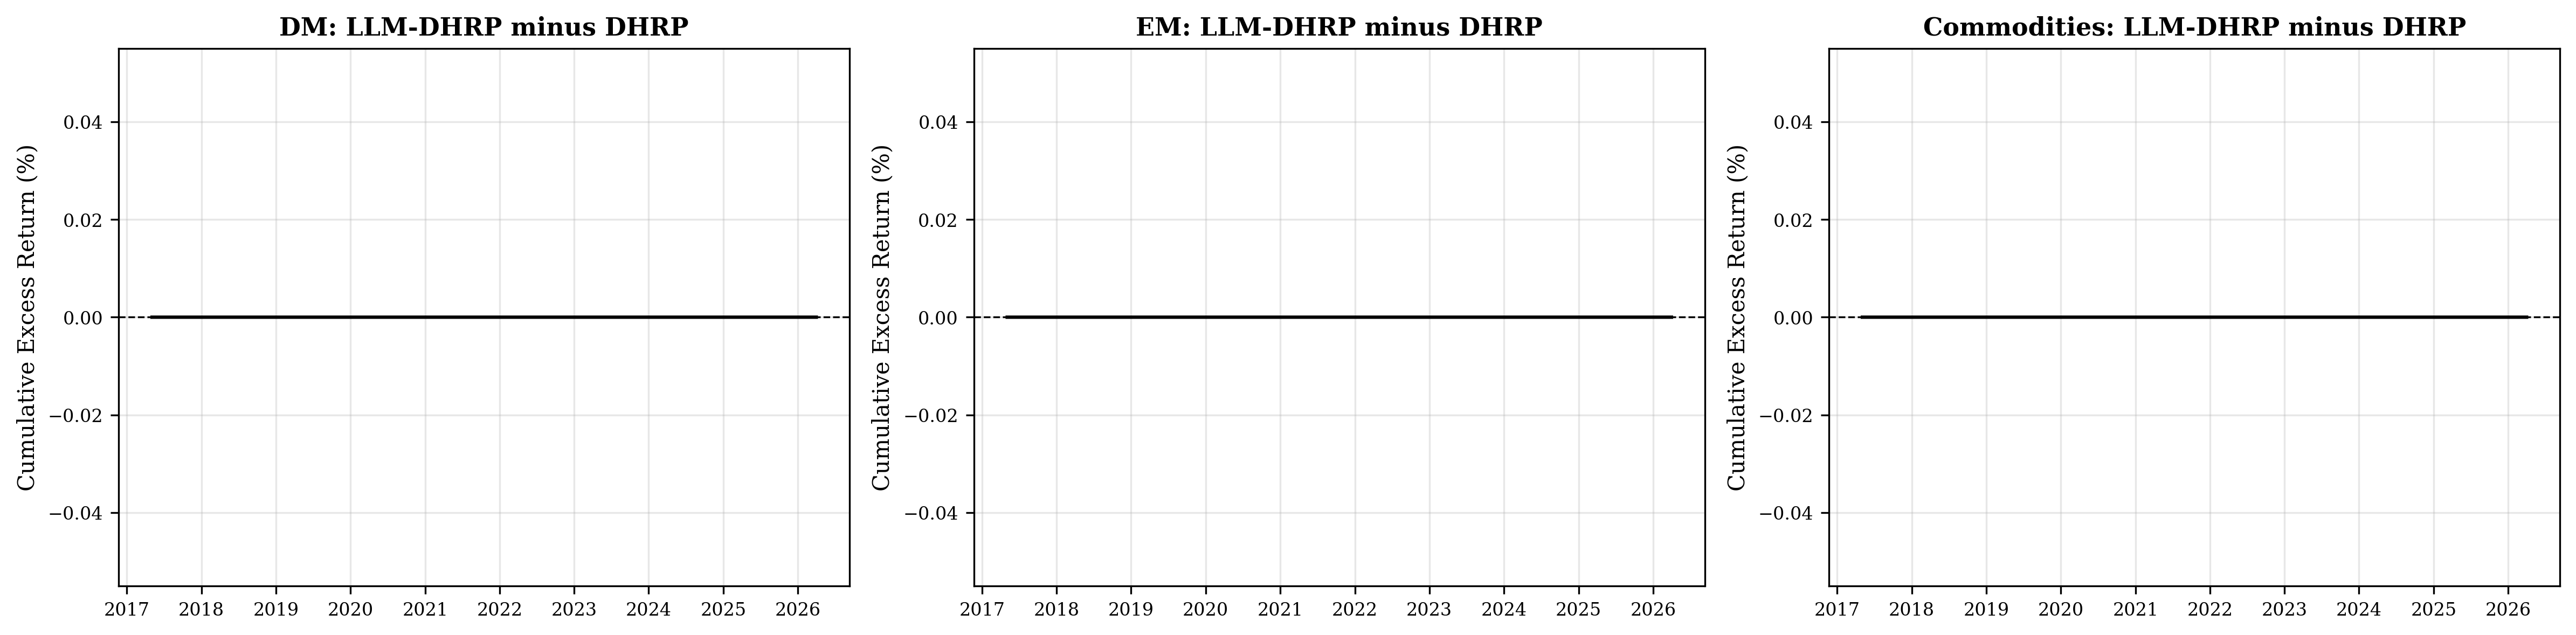

LLM delta figure saved.


In [20]:
# === CELL 12: PAPER FIGURES ===
from src.visualization.plots import plot_cumulative, plot_sharpe_bars
import matplotlib.pyplot as plt

os.makedirs('results/figures', exist_ok=True)

results_dict = {'DM': dm_res, 'EM': em_res, 'Commodities': cmd_res}
plot_cumulative(results_dict, output_dir='results/figures')
plot_sharpe_bars(results_dict, output_dir='results/figures')
print('Cumulative returns and Sharpe bar figures saved.')

# LLM-DHRP vs DHRP delta analysis
if 'LLM_DHRP' in dm_res['method'].unique():
    from src.visualization.plots import get_series
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (uname, res) in zip(axes, results_dict.items()):
        s_llm = get_series(res, 'LLM_DHRP')
        s_dhrp = get_series(res, 'DHRP')
        common = s_llm.index.intersection(s_dhrp.index)
        diff = s_llm.loc[common] - s_dhrp.loc[common]
        cum_diff = diff.cumsum() * 100
        ax.fill_between(common, cum_diff.values, 0,
                        where=cum_diff.values >= 0, alpha=0.3, color='green')
        ax.fill_between(common, cum_diff.values, 0,
                        where=cum_diff.values < 0, alpha=0.3, color='red')
        ax.plot(common, cum_diff.values, color='black', lw=1.5)
        ax.axhline(0, color='black', ls='--', lw=0.8)
        ax.set_title(f'{uname}: LLM-DHRP minus DHRP', fontweight='bold')
        ax.set_ylabel('Cumulative Excess Return (%)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/llm_delta.png', dpi=300)
    plt.show()
    print('LLM delta figure saved.')

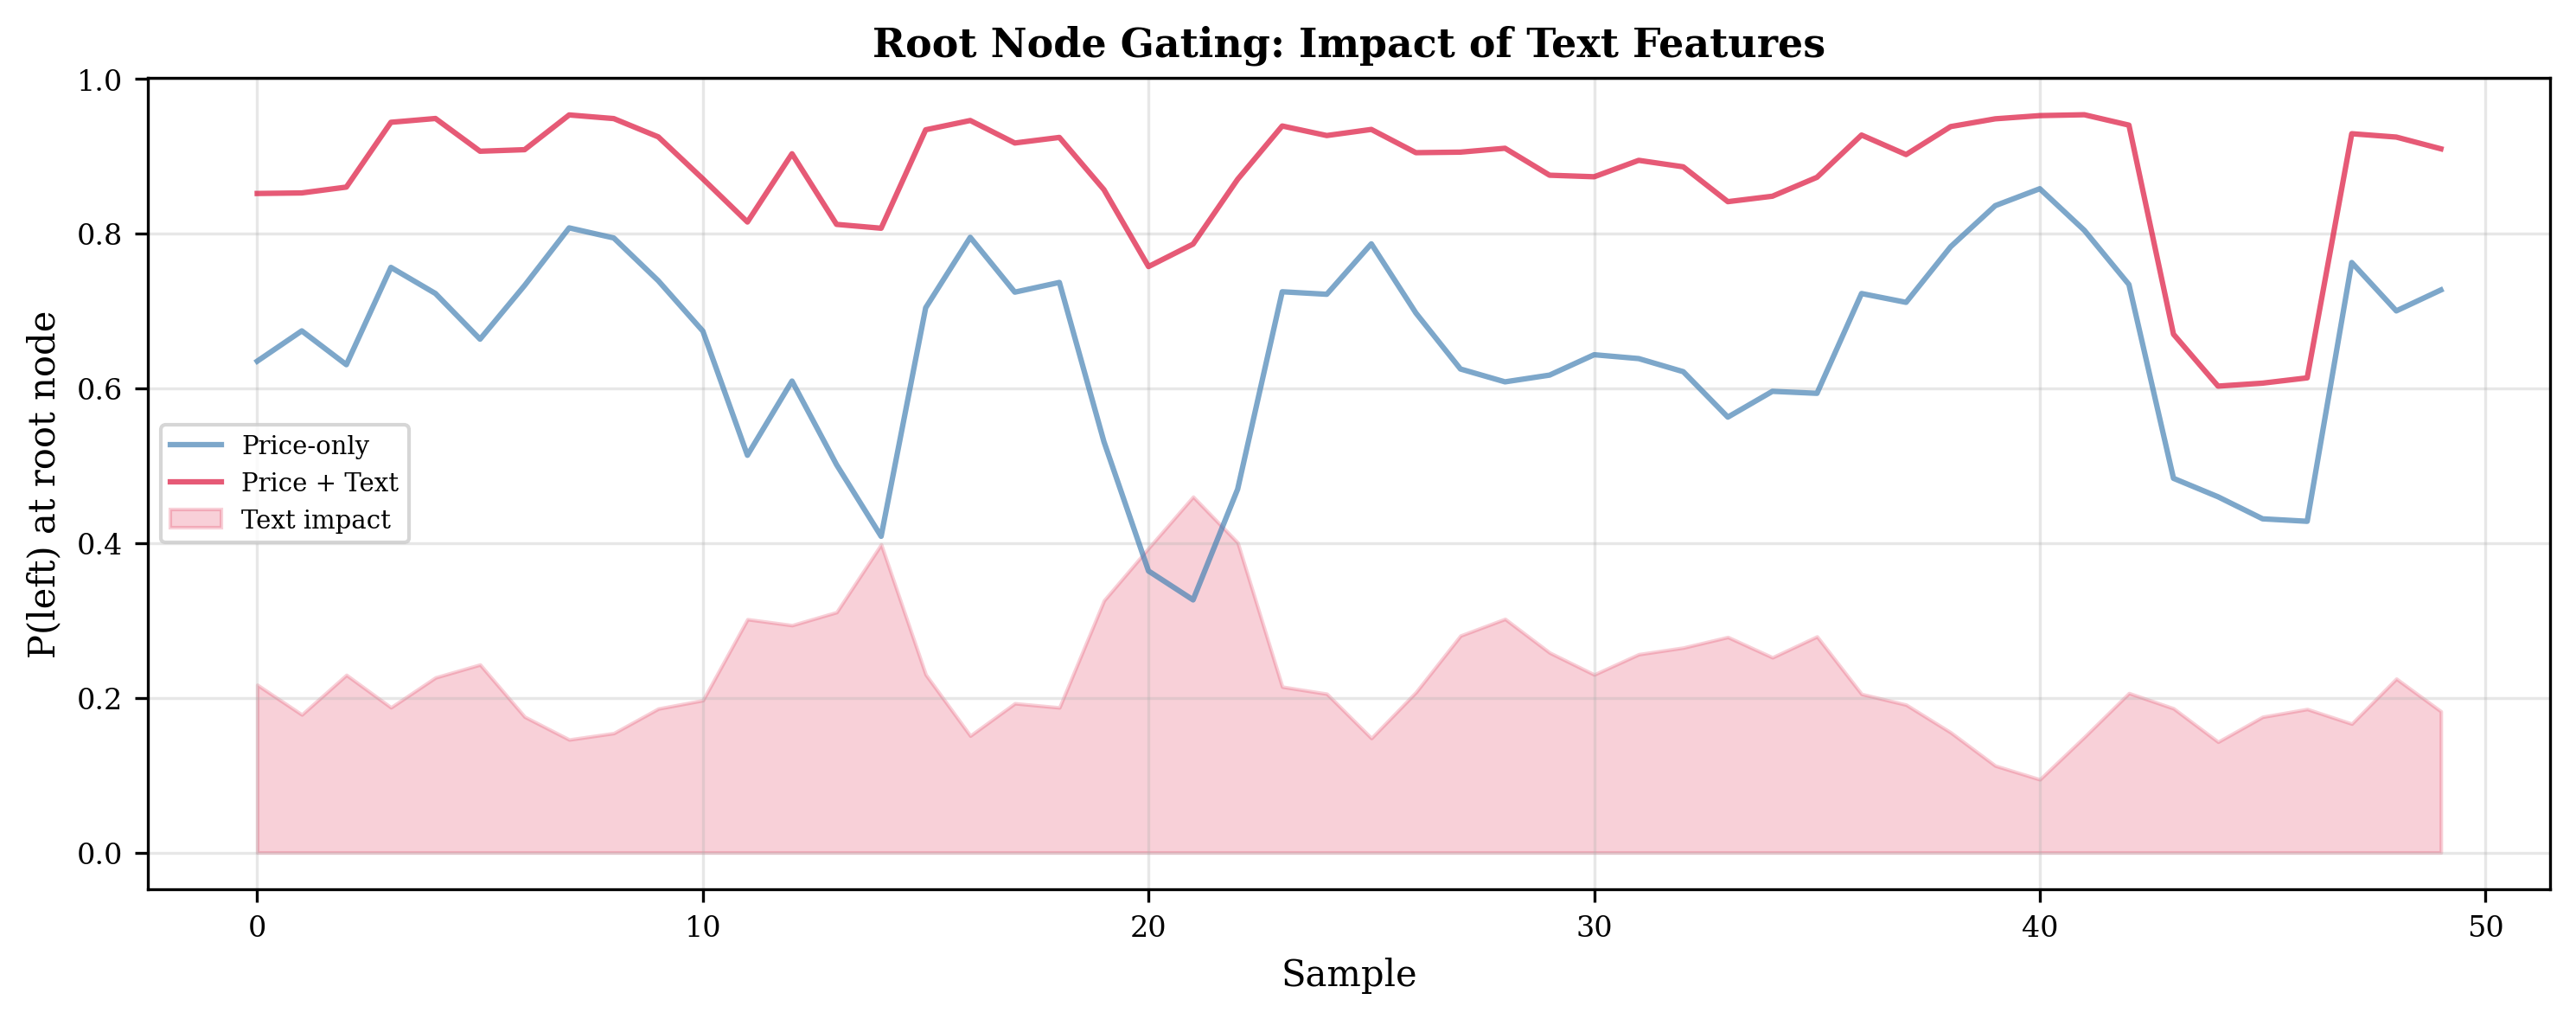

Gating interpretability figure saved.


In [21]:
# === CELL 13: GATING INTERPRETABILITY ===
# Visualize how text features change the tree routing decisions
import matplotlib.pyplot as plt
import seaborn as sns

if llm_dhrp_dm is not None:
    from src.data.feature_engineering import build_dataset, make_features
    
    X, S, R, H = build_dataset(DM_prices)
    n_samples = min(50, X.shape[0])
    
    # Compare gating with vs without text
    probs_with_text = []
    probs_without_text = []
    
    for i in range(n_samples):
        x = torch.from_numpy(X[i]).to(device)
        s = torch.from_numpy(S[i]).to(device)
        
        if text_dm is not None:
            te = torch.from_numpy(text_dm[i].mean(axis=0)).to(device)
        else:
            te = torch.randn(768).to(device)  # random for demo
        
        p_with = llm_dhrp_dm.get_gating_probs(x, s, text_emb=te)
        p_without = llm_dhrp_dm.get_gating_probs(x, s, text_emb=None)
        probs_with_text.append([p.cpu().numpy() for p in p_with])
        probs_without_text.append([p.cpu().numpy() for p in p_without])
    
    # Plot root node gating shift
    root_with = [p[0][0] for p in probs_with_text]  # P(left) at root
    root_without = [p[0][0] for p in probs_without_text]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(root_without, label='Price-only', alpha=0.7, color='steelblue')
    ax.plot(root_with, label='Price + Text', alpha=0.7, color='crimson')
    ax.fill_between(range(n_samples),
                    [a-b for a, b in zip(root_with, root_without)],
                    alpha=0.2, color='crimson', label='Text impact')
    ax.set_xlabel('Sample')
    ax.set_ylabel('P(left) at root node')
    ax.set_title('Root Node Gating: Impact of Text Features', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/gating_interpretability.png', dpi=300)
    plt.show()
    print('Gating interpretability figure saved.')
else:
    print('LLM-DHRP not trained. Skipping interpretability analysis.')

In [22]:
# === CELL 14: FINAL SUMMARY ===
print('\n' + '='*70)
print('  EXPERIMENT COMPLETE â€” PUBLICATION-GRADE BENCHMARKS')
print('='*70)

print(f'\nUniverses tested: DM ({DM_prices.shape[1]}), EM ({EM_prices.shape[1]}), CMD ({CMD_prices.shape[1]})')
print(f'Total assets: {DM_prices.shape[1] + EM_prices.shape[1] + CMD_prices.shape[1]}')
print(f'Methods compared: {sorted(dm_full["method"].unique())}')
print(f'Device used: {device}')

print('\n--- Result CSVs ---')
import glob
for f in sorted(glob.glob('results/*.csv')):
    print(f'  {f}')

print('\n--- Figures ---')
for f in sorted(glob.glob('results/figures/*.png')):
    sz = os.path.getsize(f) / 1024
    print(f'  {f} ({sz:.0f} KB)')

print('\n--- Models ---')
for f in sorted(glob.glob('results/models/*.pt')):
    sz = os.path.getsize(f) / 1024
    print(f'  {f} ({sz:.0f} KB)')

print('\n--- Benchmarks Completed ---')
print('  1. Deep baselines (MLP, Transformer, PPO)')
print('  2. Full backtest (10+ methods, 3 universes)')
print('  3. Pairwise statistical tests (Sharpe + DM, Holm-Bonferroni)')
print('  4. Ablation studies (tree depth, loss components)')
print('  5. Multi-seed robustness (5 seeds)')
print('  6. Transaction cost sensitivity + turnover')
print('  7. Regime-conditional analysis (5 macro regimes)')
print('  8. Publication figures (NeurIPS-compatible, 300 DPI)')
print('  9. Computational efficiency benchmarks')

if torch.cuda.is_available():
    print(f'\nGPU memory peak: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')


  EXPERIMENT COMPLETE â€” PUBLICATION-GRADE BENCHMARKS

Universes tested: DM (20), EM (14), CMD (10)
Total assets: 44
Methods compared: ['DHRP', 'EW', 'HRP', 'LLM_DHRP', 'MAXDIV', 'MINVAR', 'MLP', 'MV', 'PPO', 'RP', 'Transformer']
Device used: cuda

--- Result CSVs ---
  results/Commodities_regime_analysis.csv
  results/Commodities_results.csv
  results/DM_ablations.csv
  results/DM_computational_efficiency.csv
  results/DM_cost_sensitivity.csv
  results/DM_dm_tests_negative.csv
  results/DM_dm_tests_squared.csv
  results/DM_full_stats.csv
  results/DM_multiseed.csv
  results/DM_regime_analysis.csv
  results/DM_results.csv
  results/DM_sharpe_tests.csv
  results/DM_turnover.csv
  results/EM_regime_analysis.csv
  results/EM_results.csv

--- Figures ---
  results/figures/ablation_heatmap.png (59 KB)
  results/figures/cost_sensitivity.png (130 KB)
  results/figures/cumulative_returns.png (881 KB)
  results/figures/fig1_cumulative_returns.png (1011 KB)
  results/figures/fig2_sharpe_compar